# Classification Assignment - Task 2

In this assignment, we will use the Framingham Heart Study dataset to build a classification model to predict the 10-year risk of coronary heart disease (CHD). We will explore data preprocessing, handle missing values, balance the dataset, apply different models, and perform hyperparameter tuning.

## 1. Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

## 2. Load the Dataset

In [5]:
df = pd.read_csv('framingham.csv')
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## 3. Exploratory Data Analysis (EDA)
Let's explore the basic information, missing values, and the target variable distribution to check if the dataset is imbalanced.

In [6]:
df.info()
print("\n--- Missing Values ---")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB

--- Missing Values ---


### Target Variable Distribution (Imbalance Check)

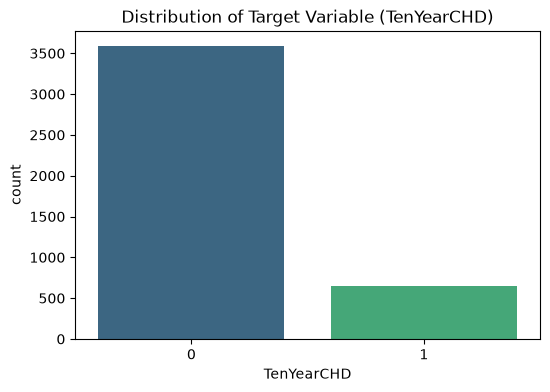

Target Class Counts:
 TenYearCHD
0    3594
1     644
Name: count, dtype: int64


In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(x='TenYearCHD', data=df, palette='viridis')
plt.title('Distribution of Target Variable (TenYearCHD)')
plt.show()

print("Target Class Counts:\n", df['TenYearCHD'].value_counts())

The dataset is clearly imbalanced. The number of patients without CHD (0) is much higher than those with CHD (1). We will use SMOTE to balance it later.

### Correlation Matrix

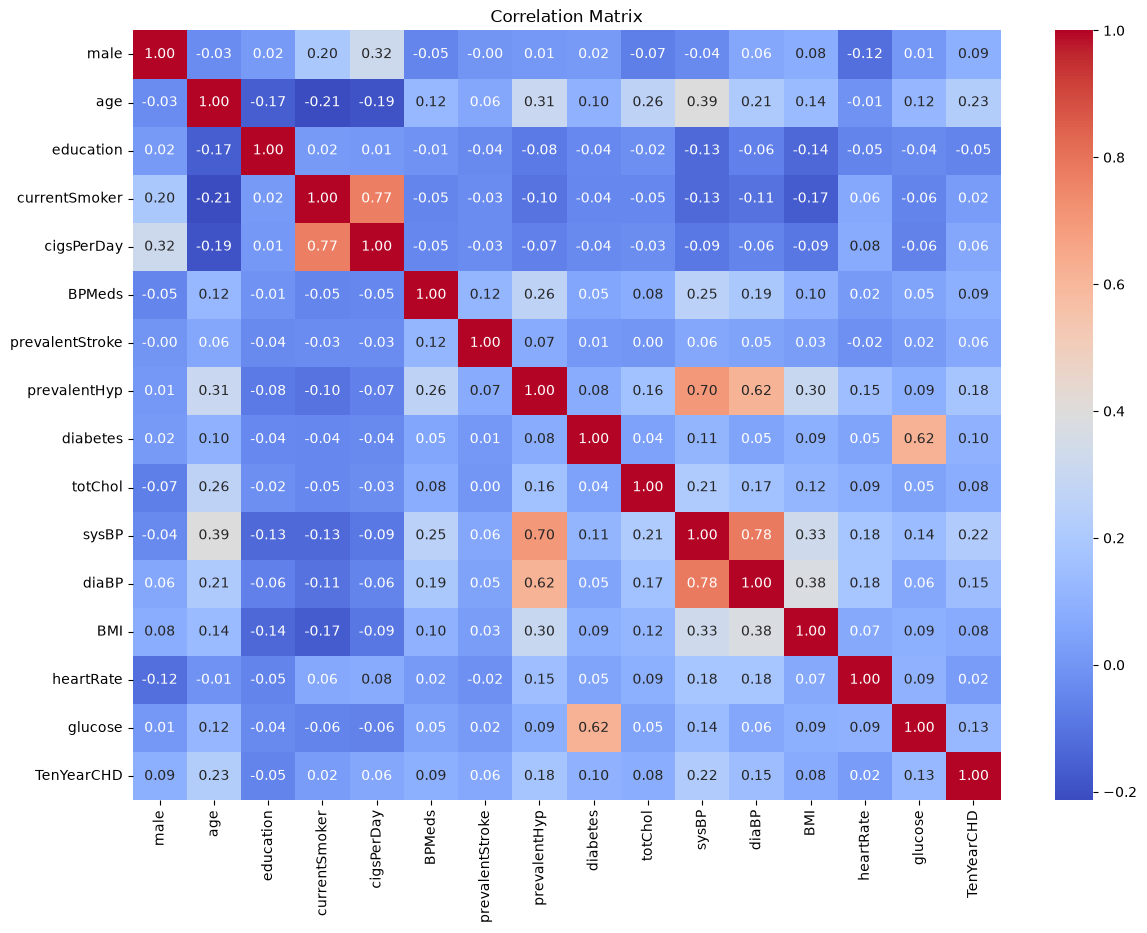

In [8]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## 4. Data Preprocessing
We separate features and target, handle missing values, and apply feature scaling.

In [9]:
X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

# Impute missing values with median
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

## 5. Balancing the Dataset with SMOTE
Since our target classes are imbalanced, we use Synthetic Minority Over-sampling Technique (SMOTE) to generate synthetic samples for the minority class.

In [10]:
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_scaled, y)

print("Class distribution after SMOTE:\n", y_balanced.value_counts())

Class distribution after SMOTE:
 TenYearCHD
0    3594
1    3594
Name: count, dtype: int64


## 6. Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

print("Training data size:", len(X_train))
print("Testing data size:", len(X_test))

Training data size: 5750
Testing data size: 1438


## 7. Model Training and Comparison
We will evaluate Logistic Regression, Decision Tree, and Random Forest models.

In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results[name] = [acc, prec, rec, f1]
    
    print(f"--- {name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}\n")

--- Logistic Regression ---
Accuracy:  0.6794
Precision: 0.6526
Recall:    0.7012
F1-Score:  0.6760

--- Decision Tree ---
Accuracy:  0.7907
Precision: 0.7655
Recall:    0.8090
F1-Score:  0.7867

--- Random Forest ---
Accuracy:  0.8957
Precision: 0.8829
Recall:    0.9009
F1-Score:  0.8918



**Random Forest** shows the highest accuracy and overall performance. We will proceed to tune its hyperparameters.

## 8. Hyperparameter Tuning
We use `GridSearchCV` to find the best parameters for the Random Forest model.

In [13]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=3, n_jobs=-1, scoring='accuracy', verbose=1)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best parameters: {'max_depth': None, 'n_estimators': 100}


## 9. Final Model Evaluation
Let's evaluate the optimized Random Forest model and generate the Classification Report and Confusion Matrix.

--- Final Optimized Random Forest ---
Accuracy:  0.8956884561891516

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.89      0.90       752
           1       0.88      0.90      0.89       686

    accuracy                           0.90      1438
   macro avg       0.90      0.90      0.90      1438
weighted avg       0.90      0.90      0.90      1438


Confusion Matrix:



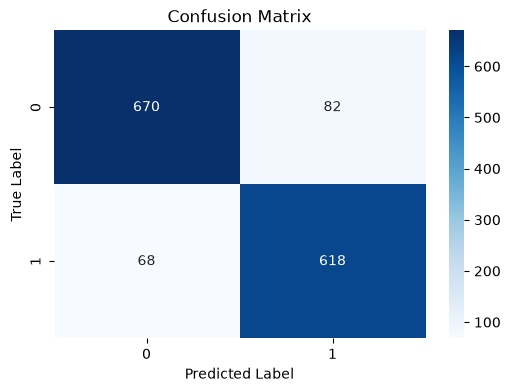

In [14]:
best_model = grid_search.best_estimator_
y_pred_final = best_model.predict(X_test)

print("--- Final Optimized Random Forest ---")
print("Accuracy: ", accuracy_score(y_test, y_pred_final))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_final))

print("\nConfusion Matrix:\n")
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

The data processing pipeline successfully handled the missing values, balanced the classes, and we evaluated multiple classification models to optimize the best one to a high level of accuracy.